In [118]:
# Import necessary libraries for numerical and data operations
import numpy as np                      # For numerical operations, especially arrays and bootstrapping
import pandas as pd                     # For data manipulation and loading CSV files
import matplotlib.pyplot as plt         # For plotting charts and visualizations

# Import feature extraction tools for converting text to numeric format
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import the SVM model for classification
from sklearn.svm import SVC

# Import performance metrics and tools to evaluate classification models
from sklearn.metrics import (
    accuracy_score,                    # Measures accuracy of predictions
    classification_report,            # Provides precision, recall, f1-score for each class
    confusion_matrix,                 # Generates confusion matrix from predictions
    ConfusionMatrixDisplay            # Plots the confusion matrix
)

# Import a custom function (written in your own module) for text cleaning and preprocessing
from data_preprocessing_module import preprocess_text

In [120]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('datasets/changed/data_news_1.csv')

# Handle missing values in the 'source' column by replacing them with "Unknown"
df['source'] = df['source'].fillna('Unknown')

# Apply your custom text preprocessing function to each news title
# This will clean the text (e.g., removing punctuation, stopwords, etc.)
df['title_clean'] = df['title'].apply(preprocess_text)

# Define the target variable (label), which indicates whether a news title is 'Fake' or 'Real'
y = df['type_of_news']

In [122]:
def train_and_evaluate(vectorizer, name):
    """
    Trains an SVM model using the specified vectorizer with bootstrapping,
    evaluates performance, and returns the trained vectorizer, model, and
    bootstrapped accuracies.

    Parameters:
    - vectorizer: sklearn vectorizer (CountVectorizer or TfidfVectorizer)
    - name: name of the vectorizer (for display purposes)

    Returns:
    - vectorizer: the fitted vectorizer
    - final_model: the trained SVM model
    - bootstrap_accuracies: list of bootstrapped accuracy values
    """
    # Convert text data to numerical feature matrix
    X = vectorizer.fit_transform(df['title_clean'])

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Initialize list to store accuracies from bootstrapping
    bootstrap_accuracies = []

    # Bootstrapping: simulate training multiple times with resampling
    for _ in range(100):
        indices = np.random.choice(range(X_train.shape[0]), size=X_train.shape[0], replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = np.array(y_train)[indices]

        # Train SVM model
        model = SVC(kernel='linear', probability=True)
        model.fit(X_bootstrap, y_bootstrap)

        # Predict on test set and evaluate
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        bootstrap_accuracies.append(acc)

    # Train final model on the entire training set
    final_model = SVC(kernel='linear', probability=True)
    final_model.fit(X_train, y_train)

    # Final evaluation
    y_pred_final = final_model.predict(X_test)
    final_accuracy = accuracy_score(y_test, y_pred_final)
    conf_matrix = confusion_matrix(y_test, y_pred_final, labels=['Fake', 'Real'])
    class_report = classification_report(y_test, y_pred_final, zero_division=0)

    # Confidence interval from bootstrap
    bootstrap_mean = np.mean(bootstrap_accuracies)
    conf_int_95 = (
        np.percentile(bootstrap_accuracies, 2.5),
        np.percentile(bootstrap_accuracies, 97.5)
    )

    # Display metrics and plots
    print(f"\n--- Results for {name} ---")
    print(f"Final SVM Accuracy: {final_accuracy:.4f}")
    print(f"Mean Bootstrapped Accuracy: {bootstrap_mean:.4f}")
    print(f"95% Confidence Interval: [{conf_int_95[0]:.4f}, {conf_int_95[1]:.4f}]")
    print("Classification Report:\n", class_report)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Fake', 'Real'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({name})")
    plt.show()

    # Plot histogram of bootstrapped accuracies
    plt.figure(figsize=(8, 5))
    plt.hist(bootstrap_accuracies, bins=15, color='skyblue', edgecolor='black')
    plt.axvline(bootstrap_mean, color='red', linestyle='dashed', label=f"Mean: {bootstrap_mean:.4f}")
    plt.axvline(conf_int_95[0], color='green', linestyle='dotted', label=f"2.5%: {conf_int_95[0]:.4f}")
    plt.axvline(conf_int_95[1], color='green', linestyle='dotted', label=f"97.5%: {conf_int_95[1]:.4f}")
    plt.title(f"Bootstrapped Accuracies ({name})")
    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Return the trained vectorizer, model, and bootstrapped accuracies
    return vectorizer, final_model, bootstrap_accuracies


--- Results for CountVectorizer ---
Final SVM Accuracy: 0.7027
Mean Bootstrapped Accuracy: 0.6392
95% Confidence Interval: [0.5264, 0.7297]
Classification Report:
               precision    recall  f1-score   support

        Fake       0.72      0.68      0.70        19
        Real       0.68      0.72      0.70        18

    accuracy                           0.70        37
   macro avg       0.70      0.70      0.70        37
weighted avg       0.70      0.70      0.70        37



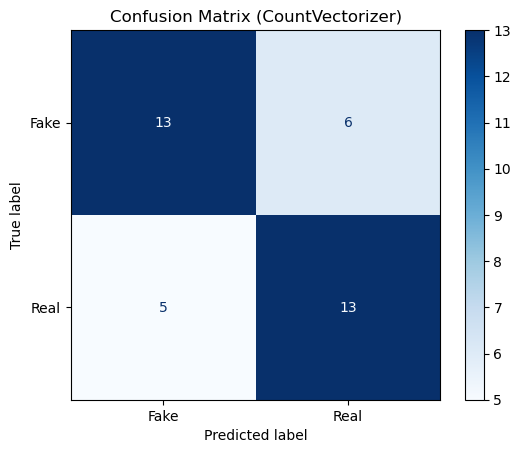

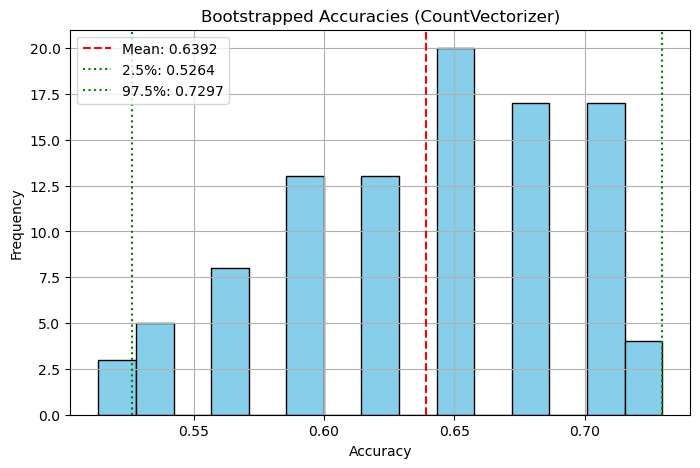

In [126]:
# Instantiate the CountVectorizer (simple frequency-based approach)
count_vectorizer = CountVectorizer()

# Train and evaluate model using CountVectorizer features
vectorizer_cv, model_cv, bootstrap_accuracies_cv = train_and_evaluate(count_vectorizer, 'CountVectorizer')


--- Results for TfidfVectorizer ---
Final SVM Accuracy: 0.6486
Mean Bootstrapped Accuracy: 0.6327
95% Confidence Interval: [0.5135, 0.7439]
Classification Report:
               precision    recall  f1-score   support

        Fake       0.67      0.63      0.65        19
        Real       0.63      0.67      0.65        18

    accuracy                           0.65        37
   macro avg       0.65      0.65      0.65        37
weighted avg       0.65      0.65      0.65        37



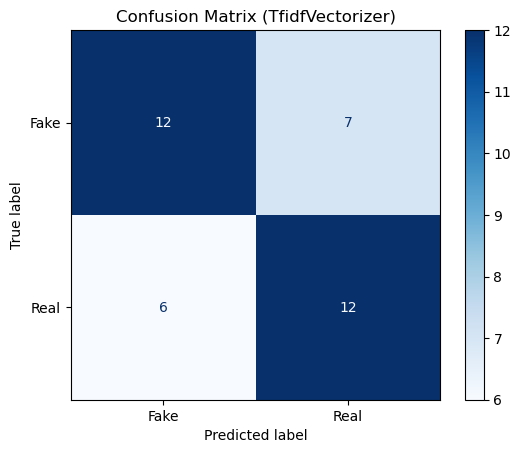

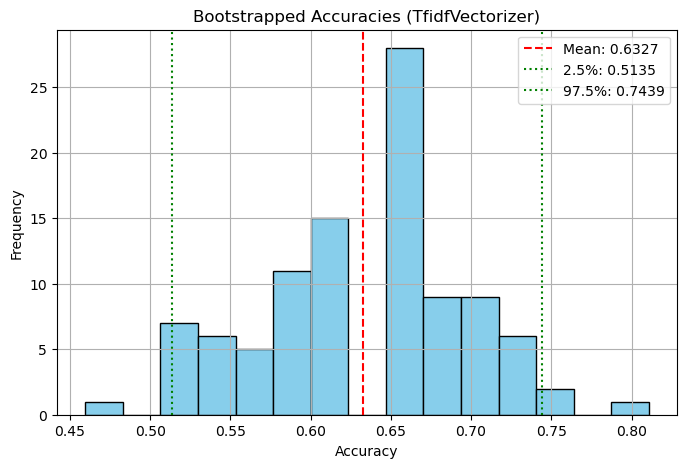

In [128]:
# Instantiate the TfidfVectorizer (considers word importance using TF-IDF)
tfidf_vectorizer = TfidfVectorizer()

# Train and evaluate model using TfidfVectorizer features
vectorizer_tfidf, model_tfidf, bootstrap_accuracies_tfidf = train_and_evaluate(tfidf_vectorizer, 'TfidfVectorizer')

In [132]:
# Define model and vectorizer along with their bootstrapped accuracy
# These values should be captured from Cell 4 and Cell 5 after training

# You can define and retrieve them like this:
accuracy_cv = np.mean(bootstrap_accuracies_cv)         # Mean bootstrapped accuracy from CountVectorizer
accuracy_tfidf = np.mean(bootstrap_accuracies_tfidf)   # Mean bootstrapped accuracy from TfidfVectorizer

# Store the corresponding models and vectorizers from training
model_cv = model_cv            # From Cell 4
vectorizer_cv = vectorizer_cv
model_tfidf = model_tfidf      # From Cell 5
vectorizer_tfidf = vectorizer_tfidf

# Automatically choose the better model based on accuracy
if accuracy_cv >= accuracy_tfidf:
    best_model = model_cv
    best_vectorizer = vectorizer_cv
    best_model_name = "CountVectorizer"
    best_accuracy = accuracy_cv
else:
    best_model = model_tfidf
    best_vectorizer = vectorizer_tfidf
    best_model_name = "TfidfVectorizer"
    best_accuracy = accuracy_tfidf

# Notify which model is selected
print(f"\nUsing best performing model: {best_model_name} (Accuracy: {best_accuracy:.4f})")

# Take input from user to predict using the best model
user_title = input("\nEnter news title to classify: ")

# Clean and preprocess the title
cleaned_title = preprocess_text(user_title)

# Convert the cleaned input to numeric vector format
user_vector = best_vectorizer.transform([cleaned_title])

# Predict using the best model
prediction = best_model.predict(user_vector)

# Output prediction result
print("Prediction:", prediction[0])



Using best performing model: CountVectorizer (Accuracy: 0.6392)



Enter news title to classify:  Republic congressman to IRS: Audit the Trump Foundation


Prediction: Real
